# IDEAL Stage 2: daily archetype clustering

This notebook starts from the saved daily electricity feature table and does not require rerunning the raw sensor loading notebook.

Input files:

- `script/outputs/stage1_preparation/daily_electricity_features_enhanced.csv`
- `script/outputs/stage1_preparation/enhanced_home_feature_matrix.csv`

Main purpose:

1. load the daily table
2. filter cluster-ready days
3. optionally apply a flat-day rule
4. run silhouette and elbow checks
5. validate k with hierarchical clustering
6. compare centroid shapes across candidate k values
7. fit the clustering model
8. build household summaries
9. plot centroid trends
10. create descriptive archetype summaries
11. save outputs

## Step 1. Load saved Stage 1 outputs

This notebook uses the saved daily table, so it does not need the earlier heavy notebook cells to be rerun.

In [20]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.vq import kmeans2
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)


def locate_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    markers = ["sensordata", "script", "metadata_and_surveys (1)"]
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError("Could not locate IDEAL project root.")


ROOT = locate_project_root()
SCRIPT_DIR = ROOT / "script"
DAILY_PATH = SCRIPT_DIR / "outputs" / "stage1_preparation" / "daily_electricity_features_enhanced.csv"
HOME_PATH = SCRIPT_DIR / "outputs" / "stage1_preparation" / "enhanced_home_feature_matrix.csv"

daily_df = pd.read_csv(DAILY_PATH, low_memory=False)
home_df = pd.read_csv(HOME_PATH, low_memory=False)
daily_df["date"] = pd.to_datetime(daily_df["date"], errors="coerce")

BLOCK_COLS = sorted(
    [col for col in daily_df.columns if col.startswith("block_") and not col.startswith("norm_")],
    key=lambda c: int(c.replace("block_", "")),
)
NORM_COLS = sorted(
    [col for col in daily_df.columns if col.startswith("norm_block_")],
    key=lambda c: int(c.replace("norm_block_", "")),
)

print(f"Loaded daily table: {daily_df.shape}")
print(f"Loaded home table: {home_df.shape}")
print(f"Profile columns: {len(NORM_COLS)}")

Loaded daily table: (12147, 105)
Loaded home table: (39, 65)
Profile columns: 12


## Step 2. Basic quality check

This checks how many days are available for clustering before any extra filtering is applied.

In [21]:
qc_summary = {
    "rows": len(daily_df),
    "homes": daily_df["homeid"].nunique(),
    "complete_days": int(daily_df["complete_day"].fillna(False).sum()),
    "normalisable_days": int(daily_df["normalisable_day"].fillna(False).sum()),
    "cluster_ready_days": int(daily_df["cluster_ready_day"].fillna(False).sum()),
    "date_min": daily_df["date"].min(),
    "date_max": daily_df["date"].max(),
}
qc_summary

{'rows': 12147,
 'homes': 39,
 'complete_days': 12100,
 'normalisable_days': 11242,
 'cluster_ready_days': 11242,
 'date_min': Timestamp('2016-08-26 00:00:00'),
 'date_max': Timestamp('2018-06-30 00:00:00')}

## Step 3. Build the clustering input matrix

This cell keeps only cluster-ready days. A flat-day threshold can optionally be applied here later once the electricity unit is confirmed.

In [22]:
USE_FLAT_DAY_FILTER = False
FLAT_DAY_THRESHOLD_W = 100

cluster_df = daily_df[daily_df["cluster_ready_day"].fillna(False)].copy()

if USE_FLAT_DAY_FILTER and FLAT_DAY_THRESHOLD_W is not None:
    cluster_df = cluster_df[cluster_df["daily_range_w"] > FLAT_DAY_THRESHOLD_W].copy()

cluster_df = cluster_df[cluster_df[NORM_COLS].notna().all(axis=1)].reset_index(drop=True)
X = cluster_df[NORM_COLS].to_numpy(dtype=float)

print(f"Clustering rows retained: {len(cluster_df)}")
print(f"Feature matrix shape: {X.shape}")

Clustering rows retained: 11242
Feature matrix shape: (11242, 12)


## Step 4. Run silhouette and elbow checks

This gives a practical comparison across candidate values of `k`. Use this together with interpretability rather than treating the highest score as an automatic answer.

In [23]:
K_RANGE = list(range(2, 11))
k_search_rows = []

for k in K_RANGE:
    centroids, labels = kmeans2(X, k, minit="points", iter=50)
    inertia = float(((X - centroids[labels]) ** 2).sum())
    k_search_rows.append({
        "k": k,
        "silhouette": silhouette_score(X, labels),
        "inertia": inertia,
    })

k_search_df = pd.DataFrame(k_search_rows)
k_search_df

,k,silhouette,inertia
0,2,0.138111,10376.603743
1,3,0.141546,9243.196518
2,4,0.150335,8570.131878
3,5,0.154838,7894.887180
4,6,0.154578,7414.811974
5,7,0.166873,6968.804312
6,8,0.171101,6721.761195
7,9,0.168951,6497.401611
8,10,0.168133,6291.211869


## Step 5. Validate k with hierarchical clustering

This step adds a Ward-linkage check on a manageable random subsample.

Use it as a structural check for whether the candidate values of `k` from the k-means search line up with natural branches in the dendrogram.

In [ ]:
HIERARCHICAL_SAMPLE_SIZE = min(2000, len(cluster_df))
HIERARCHICAL_RANDOM_STATE = 42
HIERARCHICAL_K_RANGE = list(range(2, 11))

hierarchical_sample = cluster_df.sample(HIERARCHICAL_SAMPLE_SIZE, random_state=HIERARCHICAL_RANDOM_STATE).reset_index(drop=True)
X_h = hierarchical_sample[NORM_COLS].to_numpy(dtype=float)
Z = linkage(X_h, method="ward")

hierarchical_rows = []
for k in HIERARCHICAL_K_RANGE:
    labels_h = fcluster(Z, t=k, criterion="maxclust") - 1
    if len(np.unique(labels_h)) < 2:
        continue
    hierarchical_rows.append({
        "k": k,
        "silhouette": silhouette_score(X_h, labels_h),
        "min_cluster_size": int(pd.Series(labels_h).value_counts().min()),
        "max_cluster_size": int(pd.Series(labels_h).value_counts().max()),
    })

hierarchical_k_df = pd.DataFrame(hierarchical_rows)

fig_h, ax_h = plt.subplots(figsize=(10, 5))
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45, leaf_font_size=10, ax=ax_h)
ax_h.set_title("Ward-linkage dendrogram (truncated)")
ax_h.set_xlabel("Cluster branch")
ax_h.set_ylabel("Distance")
plt.tight_layout()
plt.show()

hierarchical_k_df

## Step 6. Compare centroid shapes across candidate k values

This step focuses on interpretability rather than only on silhouette.

It is especially useful for checking whether higher-k solutions are producing genuinely distinct daily trends or just splitting a broader shape into narrow spiky subclasses.

In [ ]:
CANDIDATE_KS = [4, 5, 6, 7]
candidate_rows = []

fig_compare, axes = plt.subplots(len(CANDIDATE_KS), 1, figsize=(10, 3.5 * len(CANDIDATE_KS)), sharex=True)
if len(CANDIDATE_KS) == 1:
    axes = [axes]

plot_hours = [int(col.replace("norm_block_", "")) for col in NORM_COLS]
plot_labels = [f"{hour:02d}:00" for hour in plot_hours]

for ax, k in zip(axes, CANDIDATE_KS):
    centroids_k, labels_k = kmeans2(X, k, minit="points", iter=100)
    counts_k = pd.Series(labels_k).value_counts().sort_index()
    for cluster_id in range(k):
        ax.plot(
            plot_hours,
            centroids_k[cluster_id],
            marker="o",
            linewidth=1.8,
            label=f"C{cluster_id} (n={int(counts_k.get(cluster_id, 0))})",
        )
        candidate_rows.append({
            "k": k,
            "cluster_id": cluster_id,
            "cluster_size": int(counts_k.get(cluster_id, 0)),
            "peak_hour": plot_hours[int(np.argmax(centroids_k[cluster_id]))],
            "min_value": float(np.min(centroids_k[cluster_id])),
            "max_value": float(np.max(centroids_k[cluster_id])),
        })
    ax.set_title(f"Candidate k = {k}")
    ax.set_ylabel("Normalised load")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)

axes[-1].set_xticks(plot_hours)
axes[-1].set_xticklabels(plot_labels, rotation=45)
axes[-1].set_xlabel("Hour of day")
plt.tight_layout()
plt.show()

candidate_k_summary_df = pd.DataFrame(candidate_rows).sort_values(["k", "cluster_id"]).reset_index(drop=True)
candidate_k_summary_df

## Step 7. Fit the selected clustering model

Set `SELECTED_K` after reviewing the `k_search_df` table above.

In [24]:
SELECTED_K = 5

centroids, labels = kmeans2(X, SELECTED_K, minit="points", iter=100)
cluster_df["daily_archetype"] = labels

centroids_df = pd.DataFrame(centroids, columns=NORM_COLS)
centroids_df.insert(0, "daily_archetype", range(SELECTED_K))

cluster_df[["homeid", "date", "daily_archetype"] + NORM_COLS[:3]].head()

,homeid,date,daily_archetype,norm_block_00,norm_block_02,norm_block_04
0,61,2016-10-07,4,0.045177,0.046510,0.130899
1,61,2016-10-08,0,0.000000,0.000971,0.126179
2,61,2016-10-09,3,0.021576,0.062468,0.029275
3,61,2016-10-10,2,0.000000,0.008003,0.006418
4,61,2016-10-11,3,0.012170,0.020733,0.246050


## Step 8. Derive household-level archetype summaries

This turns daily labels into one row per home using the modal daily archetype and the share of days spent in each archetype.

In [25]:
household_modal = (
    cluster_df.groupby("homeid")["daily_archetype"]
    .agg(lambda x: x.mode().iat[0] if not x.mode().empty else pd.NA)
    .rename("household_modal_archetype")
    .reset_index()
)

household_mix = (
    cluster_df.assign(day_count=1)
    .pivot_table(index="homeid", columns="daily_archetype", values="day_count", aggfunc="sum", fill_value=0)
)
household_mix.columns = [f"archetype_{int(col)}_days" for col in household_mix.columns]
household_mix = household_mix.reset_index()

household_archetypes = household_modal.merge(household_mix, on="homeid", how="left").merge(home_df, on="homeid", how="left")
household_archetypes.head()

,homeid,household_modal_archetype,archetype_0_days,archetype_1_days,archetype_2_days,archetype_3_days,archetype_4_days,residents,income_band,hometype,occupancy,occupied_days,location,build_era,urban_rural_class,workingstatus,daily_standing_charge_pence,unit_charge_pence_per_kwh,app_bath,app_dehumidifier,app_dishwasher,app_electricheater,app_electrichob,app_electricoven,app_electricshower,app_freezer,app_fridge,app_fridgefreezer,app_gasfire,app_gashob,app_gasoven,app_grill,app_kettle,app_microwave,app_other,app_shower,app_sink,app_toaster,app_tumbledrier,app_vacuumcleaner,app_washingmachine,app_washingmachinetumbledrier,app_woodburningstove,major_app_total,other_air_conditioning,other_computer,other_dehumidifier,other_electric_blanket,other_electric_fan,other_electric_heater,other_humidifier,other_iron,other_laptop,other_media_entertainment,other_motor_vehicle,other_non_smart_phone,other_other_high_power_1,other_other_high_power_2,other_other_high_power_3,other_other_high_power_4,other_outdoor_electric_space_heater,other_outdoor_gas_space_heater,other_outdoor_hot_tub,other_outdoor_light,other_outdoor_water_feature,other_smartphone,other_sound_system,other_tablet,other_television,other_vacuum_cleaner,other_app_total
0,61,3,50,63,38,136,89,2,"£48,600 to £53,999",house_or_bungalow,multiple,2,Edinburgh,1919-1930,1,Paid work,0.33,0.12,1,0,1,0,0,1,0,1,1,0,1,4,0,0,1,1,0,1,2,0,0,1,1,0,0,17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0,2.0,1.0,14.0
1,62,4,162,76,93,109,224,2,"£43,200 to £48,599",flat,multiple,1,Edinburgh,1850-1899,1,Paid work,31.31,NaN,1,0,1,0,0,0,0,0,0,1,0,8,2,2,1,0,0,1,1,1,0,1,1,0,0,21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,1.0,1.0,14.0
2,63,1,83,303,27,31,49,2,"£54,000 to £65,999",house_or_bungalow,multiple,2,Edinburgh,1919-1930,1,Paid work,NaN,NaN,1,0,1,0,0,1,1,1,1,0,1,4,0,1,1,1,0,0,1,1,0,1,0,1,0,18,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,2.0,1.0,1.0,14.0
3,65,4,34,90,46,59,366,2,"£54,000 to £65,999",house_or_bungalow,multiple,7,Edinburgh,1945-1964,1,Paid work,15.97,NaN,0,0,1,0,0,1,1,1,1,0,0,4,0,1,1,0,0,0,1,1,0,3,1,0,0,17,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,1.0,2.0,0.0,3.0,19.0
4,73,0,198,29,89,52,121,3,Missing,flat,multiple,7,Edinburgh,1850-1899,1,Self-employed,NaN,NaN,1,0,0,0,0,0,1,0,0,1,2,4,0,0,1,0,0,0,2,0,0,0,1,0,0,13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,7.0


## Step 9. Plot centroid trends

This step visualises the mean normalised daily shape of each archetype.

These centroid lines are the main way to confirm that the clustering is separating meaningful demand trends rather than arbitrary numeric groups.

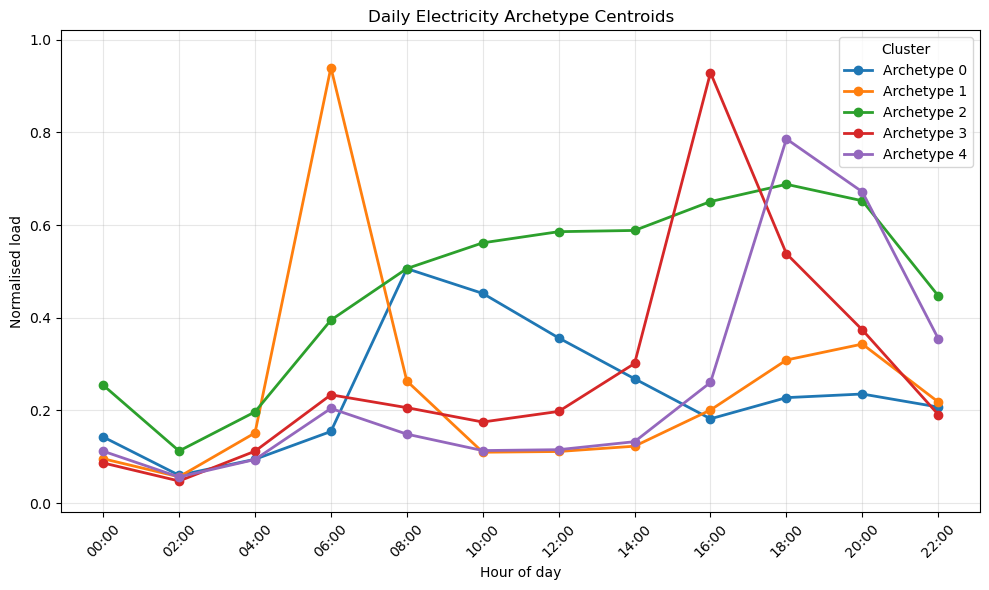

In [26]:
plot_hours = [int(col.replace("norm_block_", "")) for col in NORM_COLS]
plot_labels = [f"{hour:02d}:00" for hour in plot_hours]

fig, ax = plt.subplots(figsize=(10, 6))
for _, row in centroids_df.sort_values("daily_archetype").iterrows():
    label = row["archetype_name"]
    if "narrow-peak" in row["pattern_note"]:
        label = f"{label} ({row['pattern_note']})"
    ax.plot(
        plot_hours,
        row[NORM_COLS].to_numpy(dtype=float),
        marker="o",
        linewidth=2,
        label=label,
    )

ax.set_title("Daily Electricity Archetype Centroids")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Normalised load")
ax.set_xticks(plot_hours)
ax.set_xticklabels(plot_labels, rotation=45)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(title="Archetype", frameon=False)
plt.tight_layout()
plt.show()

## Step 10. Create descriptive archetype summaries

This step adds simple summary statistics for each archetype so the trend lines can be interpreted in behavioural terms.

In [27]:
daily_archetype_summary = (
    cluster_df.groupby("daily_archetype").agg(
        n_days=("homeid", "size"),
        n_homes=("homeid", "nunique"),
        mean_daily_total_raw=("daily_total_raw", "mean"),
        median_daily_total_raw=("daily_total_raw", "median"),
        mean_daytime_fraction_raw=("daytime_fraction_raw", "mean"),
        mean_peak_hour=("day_peak_hour", "mean"),
        weekend_share=("is_weekend", "mean"),
    )
    .reset_index()
)

season_mix = (
    cluster_df.assign(day_count=1)
    .pivot_table(index="daily_archetype", columns="season", values="day_count", aggfunc="sum", fill_value=0)
    .add_prefix("season_days_")
    .reset_index()
)

home_modal = household_archetypes[["homeid", "household_modal_archetype"]].rename(columns={"household_modal_archetype": "daily_archetype"})
home_level_summary = (
    home_modal.merge(home_df, on="homeid", how="left")
    .groupby("daily_archetype").agg(
        modal_homes=("homeid", "size"),
        mean_residents=("residents", "mean"),
        mean_major_app_total=("major_app_total", "mean"),
        mean_other_app_total=("other_app_total", "mean"),
    )
    .reset_index()
)

archetype_summary_df = (
    daily_archetype_summary
    .merge(season_mix, on="daily_archetype", how="left")
    .merge(home_level_summary, on="daily_archetype", how="left")
    .sort_values("daily_archetype")
    .reset_index(drop=True)
)

archetype_summary_df

,daily_archetype,n_days,n_homes,mean_daily_total_raw,median_daily_total_raw,mean_daytime_fraction_raw,mean_peak_hour,weekend_share,season_days_Autumn,season_days_Spring,season_days_Summer,season_days_Winter,modal_homes,mean_residents,mean_major_app_total,mean_other_app_total
0,0,2202,39,2.625793e+07,22322449.5,0.700916,11.331971,0.415985,433,674,476,619,10,2.100000,17.600000,13.900000
1,1,1443,39,2.544026e+07,24350051.0,0.510074,8.934858,0.126126,288,484,346,325,2,1.000000,18.500000,11.500000
2,2,2166,39,3.186835e+07,26712652.5,0.711735,13.007387,0.319483,337,801,333,695,6,2.666667,20.333333,17.833333
3,3,2045,39,3.012571e+07,26307611.0,0.731736,14.265526,0.308557,419,675,385,566,5,2.800000,21.000000,18.000000
4,4,3386,39,2.513534e+07,21731722.5,0.684204,15.800059,0.238039,556,1127,594,1109,16,1.937500,20.562500,15.375000


## Step 11. Save outputs

These saved files are the handoff point for profile interpretation, plotting, and write-up.

In [28]:
daily_output = SCRIPT_DIR / "outputs" / "stage2_clustering" / "daily_archetypes_enhanced.csv"
household_output = SCRIPT_DIR / "outputs" / "stage2_clustering" / "household_archetypes_enhanced.csv"
centroid_output = SCRIPT_DIR / "outputs" / "stage2_clustering" / "daily_archetype_centroids_enhanced.csv"
ksearch_output = SCRIPT_DIR / "outputs" / "stage2_clustering" / "k_search_results_enhanced.csv"
hierarchical_output = SCRIPT_DIR / "outputs" / "stage2_clustering" / "hierarchical_k_validation_enhanced.csv"
hierarchical_plot_output = SCRIPT_DIR / "outputs" / "stage2_clustering" / "hierarchical_dendrogram_enhanced.png"
candidate_k_output = SCRIPT_DIR / "outputs" / "stage2_clustering" / "candidate_k_shape_summary_enhanced.csv"
candidate_k_plot_output = SCRIPT_DIR / "outputs" / "stage2_clustering" / "candidate_k_shape_comparison_enhanced.png"
summary_output = SCRIPT_DIR / "outputs" / "stage2_clustering" / "daily_archetype_summary_enhanced.csv"
centroid_plot_output = SCRIPT_DIR / "outputs" / "stage2_clustering" / "daily_archetype_centroids_enhanced.png"

cluster_df.to_csv(daily_output, index=False)
household_archetypes.to_csv(household_output, index=False)
centroids_df.to_csv(centroid_output, index=False)
k_search_df.to_csv(ksearch_output, index=False)
hierarchical_k_df.to_csv(hierarchical_output, index=False)
candidate_k_summary_df.to_csv(candidate_k_output, index=False)
archetype_summary_df.to_csv(summary_output, index=False)
fig_h.savefig(hierarchical_plot_output, dpi=200, bbox_inches="tight")
fig_compare.savefig(candidate_k_plot_output, dpi=200, bbox_inches="tight")
fig.savefig(centroid_plot_output, dpi=200, bbox_inches="tight")

print(f"Saved daily archetypes to: {daily_output}")
print(f"Saved household archetypes to: {household_output}")
print(f"Saved centroids to: {centroid_output}")
print(f"Saved k-search results to: {ksearch_output}")
print(f"Saved hierarchical validation to: {hierarchical_output}")
print(f"Saved hierarchical dendrogram to: {hierarchical_plot_output}")
print(f"Saved candidate-k summary to: {candidate_k_output}")
print(f"Saved candidate-k plot to: {candidate_k_plot_output}")
print(f"Saved archetype summary to: {summary_output}")
print(f"Saved centroid plot to: {centroid_plot_output}")

Saved daily archetypes to: /Users/hlbao/Desktop/benv0145/IDEAL/script/daily_archetypes_enhanced.csv
Saved household archetypes to: /Users/hlbao/Desktop/benv0145/IDEAL/script/household_archetypes_enhanced.csv
Saved centroids to: /Users/hlbao/Desktop/benv0145/IDEAL/script/daily_archetype_centroids_enhanced.csv
Saved k-search results to: /Users/hlbao/Desktop/benv0145/IDEAL/script/k_search_results_enhanced.csv
Saved archetype summary to: /Users/hlbao/Desktop/benv0145/IDEAL/script/daily_archetype_summary_enhanced.csv
Saved centroid plot to: /Users/hlbao/Desktop/benv0145/IDEAL/script/daily_archetype_centroids_enhanced.png
